# V1 Experiment Evaluation

Auto-discovering evaluation notebook for the v1 experimental framework.
Analyzes results across 5 models × 4 context conditions (c0-c3).

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-discover model folders
V1_DIR = Path(".").resolve()
MODEL_DIRS = [d for d in V1_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]
print(f"Discovered model folders: {[d.name for d in MODEL_DIRS]}")

Discovered model folders: ['ministral_14b', 'gpt_4_1', 'mistral_medium', 'ministral_3b']


In [2]:
def load_results(model_dir: Path) -> list[dict]:
    """Load all JSON result files from a model directory."""
    results = []
    for json_file in model_dir.glob("*.json"):
        with open(json_file) as f:
            data = json.load(f)
            data["_file"] = json_file.name
            data["_model_dir"] = model_dir.name
            results.append(data)
    return results

# Load all results
all_results = []
for model_dir in MODEL_DIRS:
    all_results.extend(load_results(model_dir))

print(f"Loaded {len(all_results)} result files")

Loaded 4 result files


In [3]:
def extract_metrics(result: dict) -> list[dict]:
    """Extract per-dataset metrics from a result file."""
    rows = []
    config = result.get("config", {})
    model_dir = result.get("_model_dir", "unknown")
    experiment = config.get("experiment", {}).get("experiment_name", "unknown")
    model = config.get("llm", {}).get("model", "unknown")
    context_sources = config.get("context", {}).get("sources", [])
    
    # JSON uses "datasets" key, not "results"
    for dataset, metrics in result.get("datasets", {}).items():
        reports = metrics.get("reports", {})
        for manipulation in ["original", "content_only", "shuffle"]:
            report = reports.get(manipulation, {})
            macro_f1 = report.get("macro avg", {}).get("f1-score", np.nan)
            accuracy = report.get("accuracy", np.nan)
            
            rows.append({
                "model_dir": model_dir,
                "model": model,
                "context": experiment,
                "context_sources": ", ".join(context_sources),
                "dataset": dataset,
                "manipulation": manipulation,
                "macro_f1": macro_f1,
                "accuracy": accuracy,
            })
    return rows

# Build flat DataFrame
rows = []
for result in all_results:
    rows.extend(extract_metrics(result))

df = pd.DataFrame(rows)
print(f"Built DataFrame with {len(df)} rows")
df.head(10)

Built DataFrame with 120 rows


,model_dir,model,context,context_sources,dataset,manipulation,macro_f1,accuracy
0,ministral_14b,ministral-14b-latest,c1,definition,ABSTRCT,original,0.367150,0.566667
1,ministral_14b,ministral-14b-latest,c1,definition,ABSTRCT,content_only,0.629630,0.633333
2,ministral_14b,ministral-14b-latest,c1,definition,ABSTRCT,shuffle,0.400000,0.466667
3,ministral_14b,ministral-14b-latest,c1,definition,ACQUA,original,0.828571,0.833333
4,ministral_14b,ministral-14b-latest,c1,definition,ACQUA,content_only,0.652778,0.666667
5,ministral_14b,ministral-14b-latest,c1,definition,ACQUA,shuffle,0.554286,0.566667
6,ministral_14b,ministral-14b-latest,c1,definition,AEC,original,0.471210,0.500000
7,ministral_14b,ministral-14b-latest,c1,definition,AEC,content_only,0.397321,0.400000
8,ministral_14b,ministral-14b-latest,c1,definition,AEC,shuffle,0.444444,0.533333
9,ministral_14b,ministral-14b-latest,c1,definition,AFS,original,0.550000,0.600000


## C1 Fallback for C2/C3 Aggregate Calculations

**Important:** c2 and c3 only run on 4 datasets with annotation guidelines:
- ABSTRCT, ARGUMINSCI, PE, USELEC

The remaining 6 datasets (ACQUA, AEC, AFS, FINARG, IAM, SCIARK) don't have guidelines, so:
- **c2/c3 cannot provide additional context beyond c1 for these datasets**
- **For aggregate metrics, we use c1 results as the effective c2/c3 performance**

This ensures fair 10-dataset comparisons across all context conditions.

In [4]:
# =============================================================================
# C1 FALLBACK LOGIC FOR C2/C3
# =============================================================================
# Datasets WITH guidelines (run in c2/c3):
GUIDELINE_DATASETS = {"ABSTRCT", "ARGUMINSCI", "PE", "USELEC"}

# Datasets WITHOUT guidelines (use c1 results for c2/c3):
NO_GUIDELINE_DATASETS = {"ACQUA", "AEC", "AFS", "FINARG", "IAM", "SCIARK"}

def fill_c2_c3_with_c1_fallback(df: pd.DataFrame) -> pd.DataFrame:
    """
    For c2/c3 aggregate calculations, fill missing datasets with c1 results.
    
    c2/c3 only run on 4 datasets (ABSTRCT, ARGUMINSCI, PE, USELEC).
    For the other 6 datasets, we use c1 results since guidelines don't exist.
    
    IMPORTANT: Only applies fallback if actual c2/c3 results exist!
    If only c1 experiments have been run, no fallback is applied.
    
    Returns a new DataFrame with c1 values copied to c2/c3 for non-guideline datasets.
    """
    if df.empty:
        return df
    
    df_filled = df.copy()
    
    # Get c1 results for non-guideline datasets
    c1_fallback = df[
        (df["context"] == "c1") & 
        (df["dataset"].isin(NO_GUIDELINE_DATASETS))
    ].copy()
    
    # Only add fallback if we have c1 data
    if c1_fallback.empty:
        print("No c1 data available yet - fallback not applied")
        return df_filled
    
    # Get existing contexts in the data
    existing_contexts = df["context"].unique()
    
    # Only add fallback for c2/c3 if those experiments actually exist
    for target_context in ["c2", "c3"]:
        # Check if actual c2/c3 results exist (on guideline datasets)
        actual_results_exist = (
            (df["context"] == target_context) & 
            (df["dataset"].isin(GUIDELINE_DATASETS))
        ).any()
        
        if actual_results_exist:
            fallback_rows = c1_fallback.copy()
            fallback_rows["context"] = target_context
            fallback_rows["context_sources"] = "[c1 fallback]"
            df_filled = pd.concat([df_filled, fallback_rows], ignore_index=True)
            print(f"Added c1 fallback for {target_context} (actual {target_context} results exist)")
        elif target_context in existing_contexts:
            print(f"Warning: {target_context} exists but has no guideline datasets - check data")
    
    return df_filled

# Create filled DataFrame for aggregate calculations
df_filled = fill_c2_c3_with_c1_fallback(df)

# Show what was added
if not df_filled.empty:
    actual_contexts = df["context"].unique()
    filled_contexts = df_filled["context"].unique()
    print(f"\nOriginal df: {len(df)} rows, contexts: {sorted(actual_contexts)}")
    print(f"Filled df:   {len(df_filled)} rows, contexts: {sorted(filled_contexts)}")
    
    # Show c2/c3 details only if they exist
    for ctx in ["c2", "c3"]:
        if ctx in filled_contexts:
            ctx_datasets = df_filled[df_filled["context"] == ctx]["dataset"].unique()
            print(f"\n{ctx} datasets: {sorted(ctx_datasets)}")
else:
    print("No data loaded yet")


Original df: 120 rows, contexts: ['c1']
Filled df:   120 rows, contexts: ['c1']


## Performance Overview

In [5]:
# =============================================================================
# USING df_filled: c2/c3 include c1 fallback for non-guideline datasets
# =============================================================================
original_df_filled = df_filled[df_filled["manipulation"] == "original"]

pivot_f1 = original_df_filled.pivot_table(
    values="macro_f1",
    index="model_dir",
    columns="context",
    aggfunc="mean"
)

# Reorder columns if they exist
col_order = [c for c in ["c0", "c1", "c2", "c3"] if c in pivot_f1.columns]
if col_order:
    pivot_f1 = pivot_f1[col_order]

print("Mean Macro-F1 (Original Text) by Model × Context")
print("NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets")
pivot_f1.round(3)

Mean Macro-F1 (Original Text) by Model × Context
NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets


context,c1
model_dir,
gpt_4_1,0.650
ministral_14b,0.585
ministral_3b,0.571
mistral_medium,0.636


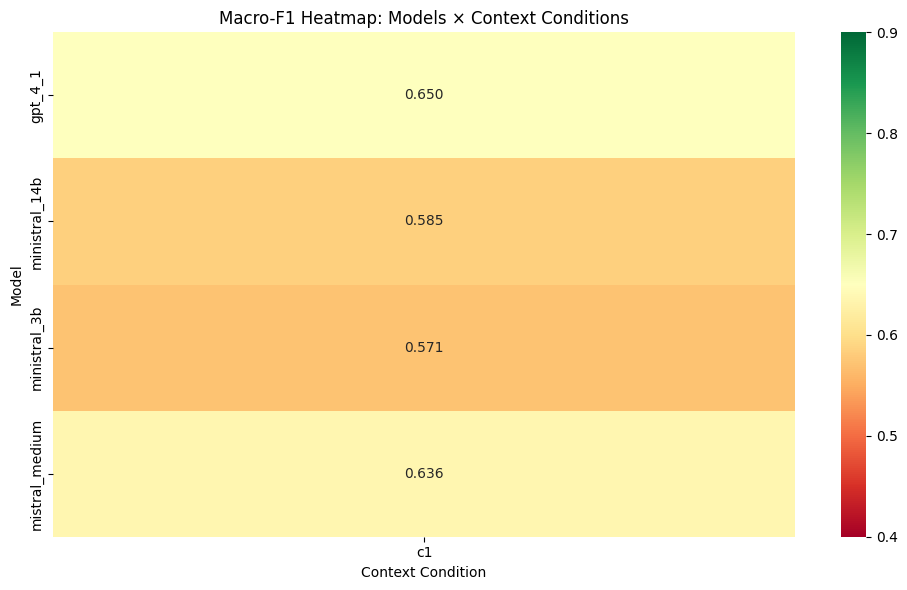

In [6]:
# F1 Heatmap
if not pivot_f1.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.4, vmax=0.9)
    plt.title("Macro-F1 Heatmap: Models × Context Conditions")
    plt.xlabel("Context Condition")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for heatmap")

## Delta Analysis (Shortcut Learning)

In [7]:
# Calculate deltas: Content-Only and Shuffle vs Original
# Using df_filled for consistent 10-dataset comparison across all contexts
def calculate_deltas(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate delta_content_only and delta_shuffle for each model/context/dataset."""
    pivot = df.pivot_table(
        values="macro_f1",
        index=["model_dir", "context", "dataset"],
        columns="manipulation",
        aggfunc="mean"
    ).reset_index()
    
    if "original" in pivot.columns:
        if "content_only" in pivot.columns:
            pivot["delta_content_only"] = pivot["content_only"] - pivot["original"]
        if "shuffle" in pivot.columns:
            pivot["delta_shuffle"] = pivot["shuffle"] - pivot["original"]
    
    return pivot

deltas_df = calculate_deltas(df_filled)  # Using df_filled!
deltas_df.head()

manipulation,model_dir,context,dataset,content_only,original,shuffle,delta_content_only,delta_shuffle
0,gpt_4_1,c1,ABSTRCT,0.566185,0.554286,0.444444,0.011899,-0.109841
1,gpt_4_1,c1,ACQUA,0.401709,0.722222,0.682726,-0.320513,-0.039496
2,gpt_4_1,c1,AEC,0.576380,0.597070,0.206349,-0.020690,-0.390720
3,gpt_4_1,c1,AFS,0.625000,0.400000,0.217054,0.225000,-0.182946
4,gpt_4_1,c1,ARGUMINSCI,0.597070,0.764310,0.403409,-0.167240,-0.360901


In [8]:
# Mean deltas by model and context
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    delta_summary = deltas_df.groupby(["model_dir", "context"])[["delta_content_only", "delta_shuffle"]].mean()
    print("Mean Deltas (negative = performance drop under manipulation)")
    display(delta_summary.round(3))
else:
    print("Not enough manipulations to calculate deltas")

Mean Deltas (negative = performance drop under manipulation)


,manipulation,delta_content_only,delta_shuffle
model_dir,context,,
gpt_4_1,c1,-0.062,-0.286
ministral_14b,c1,-0.068,-0.163
ministral_3b,c1,-0.076,-0.130
mistral_medium,c1,-0.126,-0.222


## Per-Dataset Performance

In [9]:
# Per-dataset F1 for c1 (definition context)
c1_original = df[(df["context"] == "c1") & (df["manipulation"] == "original")]

if not c1_original.empty:
    per_dataset = c1_original.pivot_table(
        values="macro_f1",
        index="dataset",
        columns="model_dir",
        aggfunc="mean"
    )
    print("c1 (Definition) Macro-F1 by Dataset × Model")
    display(per_dataset.round(3))
else:
    print("No c1 results available")

c1 (Definition) Macro-F1 by Dataset × Model


model_dir,gpt_4_1,ministral_14b,ministral_3b,mistral_medium
dataset,,,,
ABSTRCT,0.554,0.367,0.661,0.665
ACQUA,0.722,0.829,0.667,0.799
AEC,0.597,0.471,0.444,0.514
AFS,0.400,0.550,0.593,0.471
ARGUMINSCI,0.764,0.360,0.486,0.576
FINARG,0.665,0.593,0.633,0.670
IAM,0.799,0.665,0.428,0.700
PE,0.623,0.665,0.623,0.566
SCIARK,0.722,0.722,0.623,0.764


## Context Ladder Visualization

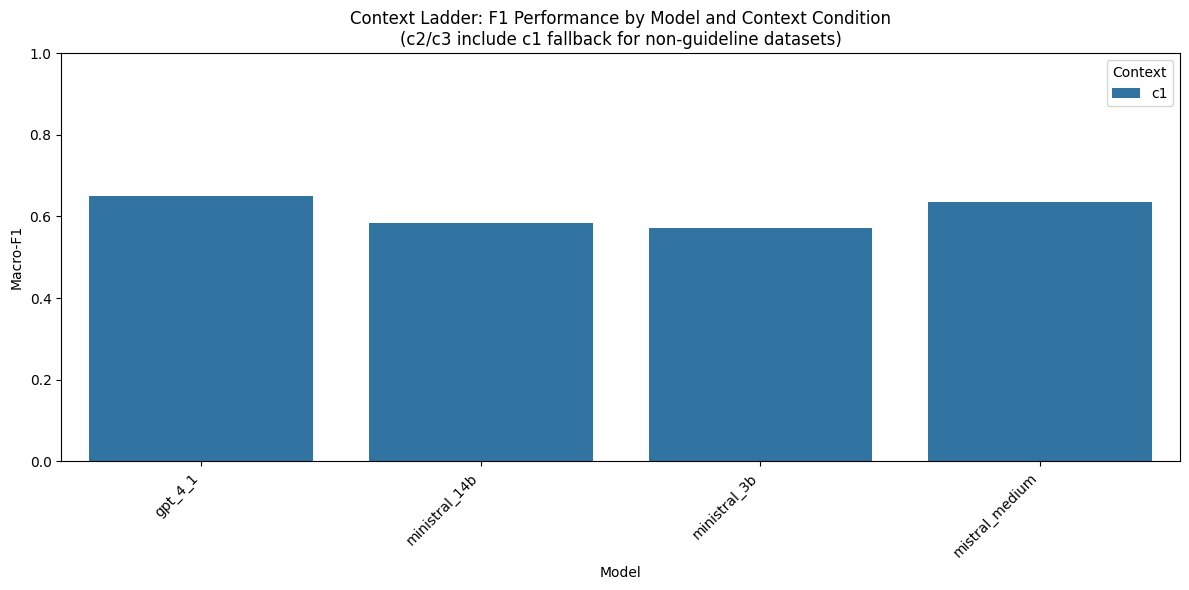

In [10]:
# Bar chart: F1 across context conditions for each model
# Using df_filled for fair 10-dataset comparison (c2/c3 include c1 fallback)
if not original_df_filled.empty:
    context_ladder = original_df_filled.groupby(["model_dir", "context"])["macro_f1"].mean().reset_index()
    
    # Sort contexts
    context_order = ["c0", "c1", "c2", "c3"]
    context_ladder["context"] = pd.Categorical(
        context_ladder["context"], 
        categories=[c for c in context_order if c in context_ladder["context"].unique()],
        ordered=True
    )
    context_ladder = context_ladder.sort_values("context")
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=context_ladder, x="model_dir", y="macro_f1", hue="context")
    plt.title("Context Ladder: F1 Performance by Model and Context Condition\n(c2/c3 include c1 fallback for non-guideline datasets)")
    plt.xlabel("Model")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1)
    plt.legend(title="Context")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for context ladder")

## Summary Statistics

In [11]:
# Summary: Mean F1, Std by model/context
# Using df_filled for consistent 10-dataset comparison
if not original_df_filled.empty:
    summary = original_df_filled.groupby(["model_dir", "context"])["macro_f1"].agg(["mean", "std", "count"])
    summary.columns = ["Mean F1", "Std", "N Datasets"]
    print("Summary Statistics (Original Text)")
    print("NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets")
    display(summary.round(3))
else:
    print("No data available for summary")

Summary Statistics (Original Text)
NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets


,,Mean F1,Std,N Datasets
model_dir,context,,,
gpt_4_1,c1,0.650,0.116,10
ministral_14b,c1,0.585,0.151,10
ministral_3b,c1,0.571,0.089,10
mistral_medium,c1,0.636,0.105,10


In [12]:
# Export results tables
if len(df) > 0:
    # Raw results (actual experiment outputs only)
    raw_path = V1_DIR / "results_raw.csv"
    df.to_csv(raw_path, index=False)
    print(f"Exported raw results to {raw_path}")
    
    # Filled results (c2/c3 include c1 fallback for non-guideline datasets)
    filled_path = V1_DIR / "results_filled.csv"
    df_filled.to_csv(filled_path, index=False)
    print(f"Exported filled results to {filled_path}")
    print("  -> Use results_filled.csv for aggregate comparisons across context conditions")
else:
    print("No results to export yet")

Exported raw results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v1/results_raw.csv
Exported filled results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v1/results_filled.csv
  -> Use results_filled.csv for aggregate comparisons across context conditions


## Comprehensive Performance Tables

In [13]:
# =============================================================================
# TABLE 1: F1 Scores by Model x Context x Dataset
# =============================================================================

all_datasets = sorted(df["dataset"].unique())
original_only = df[df["manipulation"] == "original"]

# Pivot: rows = (model_dir, context), columns = dataset
f1_pivot = original_only.pivot_table(
    values="macro_f1",
    index=["model_dir", "context"],
    columns="dataset",
    aggfunc="mean"
)
f1_pivot["Avg"] = f1_pivot.mean(axis=1)

# Sort by context order
context_order = {"c0": 0, "c1": 1, "c2": 2, "c3": 3}
f1_pivot = f1_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 Scores (Original Text) ===\n")
print(f1_pivot.round(3).to_string())

styled_f1 = f1_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).format("{:.3f}", na_rep="-")
display(styled_f1)

=== F1 Scores (Original Text) ===

dataset                 ABSTRCT  ACQUA    AEC    AFS  ARGUMINSCI  FINARG    IAM     PE  SCIARK  USELEC    Avg
model_dir      context                                                                                       
gpt_4_1        c1         0.554  0.722  0.597  0.400       0.764   0.665  0.799  0.623   0.722   0.653  0.650
ministral_14b  c1         0.367  0.829  0.471  0.550       0.360   0.593  0.665  0.665   0.722   0.623  0.585
ministral_3b   c1         0.661  0.667  0.444  0.593       0.486   0.633  0.428  0.623   0.623   0.550  0.571
mistral_medium c1         0.665  0.799  0.514  0.471       0.576   0.670  0.700  0.566   0.764   0.633  0.636


,dataset,ABSTRCT,ACQUA,AEC,AFS,ARGUMINSCI,FINARG,IAM,PE,SCIARK,USELEC,Avg
model_dir,context,,,,,,,,,,,
gpt_4_1,c1,0.554,0.722,0.597,0.400,0.764,0.665,0.799,0.623,0.722,0.653,0.650
ministral_14b,c1,0.367,0.829,0.471,0.550,0.360,0.593,0.665,0.665,0.722,0.623,0.585
ministral_3b,c1,0.661,0.667,0.444,0.593,0.486,0.633,0.428,0.623,0.623,0.550,0.571
mistral_medium,c1,0.665,0.799,0.514,0.471,0.576,0.670,0.700,0.566,0.764,0.633,0.636


In [14]:
# =============================================================================
# TABLE 2: Manipulation Sensitivity (Delta values)
# =============================================================================
# More negative delta = larger performance drop = relies on linguistic structure

delta_cols = ["delta_content_only", "delta_shuffle"]
if all(c in deltas_df.columns for c in delta_cols):
    # Aggregate deltas by model/context
    delta_agg = deltas_df.groupby(["model_dir", "context"]).agg({
        "delta_content_only": "mean",
        "delta_shuffle": "mean",
        "dataset": "count"
    }).rename(columns={"dataset": "n_datasets"})
    
    # Add mean absolute delta
    delta_agg["mean_abs_delta"] = (
        delta_agg["delta_content_only"].abs() + delta_agg["delta_shuffle"].abs()
    ) / 2
    
    # Sort by context order
    delta_agg = delta_agg.sort_index(
        key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
    )
    
    print("=== Manipulation Sensitivity (Delta values) ===")
    print("More negative = higher sensitivity to manipulation\n")
    print(delta_agg.round(3).to_string())
    
    styled_delta = delta_agg.style.background_gradient(
        subset=["delta_content_only", "delta_shuffle"],
        cmap="RdYlGn_r",  # Reversed: negative (green) to positive (red)
        vmin=-0.4, vmax=0.1
    ).background_gradient(
        subset=["mean_abs_delta"],
        cmap="RdYlGn",
        vmin=0.0, vmax=0.3
    ).format("{:.3f}")
    display(styled_delta)
else:
    print("Insufficient manipulation data for delta analysis")

=== Manipulation Sensitivity (Delta values) ===
More negative = higher sensitivity to manipulation

manipulation            delta_content_only  delta_shuffle  n_datasets  mean_abs_delta
model_dir      context                                                               
gpt_4_1        c1                   -0.062         -0.286          10           0.174
ministral_14b  c1                   -0.068         -0.163          10           0.115
ministral_3b   c1                   -0.076         -0.130          10           0.103
mistral_medium c1                   -0.126         -0.222          10           0.174


,manipulation,delta_content_only,delta_shuffle,n_datasets,mean_abs_delta
model_dir,context,,,,
gpt_4_1,c1,-0.062,-0.286,10.000,0.174
ministral_14b,c1,-0.068,-0.163,10.000,0.115
ministral_3b,c1,-0.076,-0.130,10.000,0.103
mistral_medium,c1,-0.126,-0.222,10.000,0.174


In [15]:
# =============================================================================
# TABLE 3: F1 by Manipulation (original, content_only, shuffle) per Dataset
# =============================================================================

manip_pivot = df.pivot_table(
    values="macro_f1",
    index=["model_dir", "context", "dataset"],
    columns="manipulation",
    aggfunc="mean"
)

# Reorder columns
col_order = [c for c in ["original", "content_only", "shuffle"] if c in manip_pivot.columns]
manip_pivot = manip_pivot[col_order]
manip_pivot["Avg"] = manip_pivot.mean(axis=1)

# Sort by context order
manip_pivot = manip_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 by Manipulation per Dataset ===\n")
print(manip_pivot.round(3).to_string())

styled_manip = manip_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).format("{:.3f}", na_rep="-")
display(styled_manip)

=== F1 by Manipulation per Dataset ===

manipulation                       original  content_only  shuffle    Avg
model_dir      context dataset                                           
gpt_4_1        c1      ABSTRCT        0.554         0.566    0.444  0.522
                       ACQUA          0.722         0.402    0.683  0.602
                       AEC            0.597         0.576    0.206  0.460
                       AFS            0.400         0.625    0.217  0.414
                       ARGUMINSCI     0.764         0.597    0.403  0.588
                       FINARG         0.665         0.466    0.333  0.488
                       IAM            0.799         0.864    0.333  0.666
                       PE             0.623         0.569    0.318  0.503
                       SCIARK         0.722         0.697    0.384  0.601
                       USELEC         0.653         0.514    0.317  0.494
ministral_14b  c1      ABSTRCT        0.367         0.630    0.400  0.46